# Plotting Check: Three-Lens Ray Diagram

This notebook builds a simple 3-lens model and uses `temgym_core.plotting.plot_model` to verify that `plotting.py` renders components and ray bundles correctly.

In [1]:
import jax
import matplotlib.pyplot as plt

from temgym_core.components import Detector, Lens
from temgym_core.plotting import PlotParams, legacy_beam_plot_params, plot_model
from temgym_core.source import ParallelBeam

jax.config.update("jax_enable_x64", True)

In [2]:
# Input ray bundle
source = ParallelBeam(z=0.0, radius=1.2e-3)
rays_in = source.make_rays(num=121, random=False)

# Three thin lenses and a detector plane
components = [
    Lens(z=0.20, focal_length=0.18),
    Lens(z=0.45, focal_length=-0.30),
    Lens(z=0.80, focal_length=0.22),
    Detector(z=1.10, pixel_size=(15e-6, 15e-6), shape=(512, 512)),
]

components

[Lens(z=0.2, focal_length=0.18, x0=0.0, y0=0.0),
 Lens(z=0.45, focal_length=-0.3, x0=0.0, y0=0.0),
 Lens(z=0.8, focal_length=0.22, x0=0.0, y0=0.0),
 Detector(z=1.1, pixel_size=(1.5e-05, 1.5e-05), shape=(512, 512), rotation=0.0, centre=(0.0, 0), flip_y=False)]

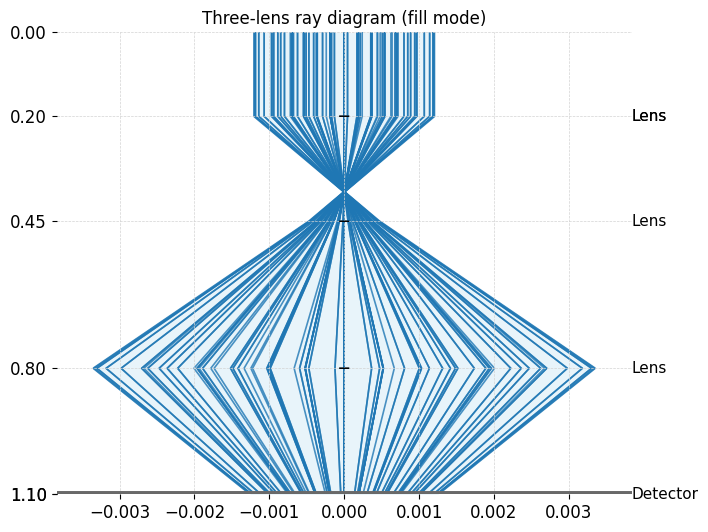

In [3]:
# Main check: filled envelope style
fig, ax = plot_model(
    components=components,
    rays=rays_in,
    plot_params=legacy_beam_plot_params(
        figsize=(6, 10),
        label_fontsize=11,
    ),
    band_mode="fill",
    yscale="linear",
)
ax.set_title("Three-lens ray diagram (legacy solid-beam mode)")
plt.show()

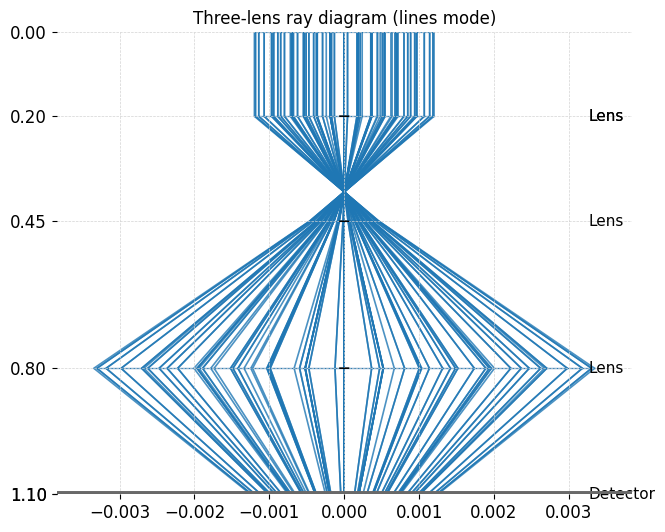

In [4]:
# Optional second view: line-segment bundle style
fig, ax = plt.subplots(figsize=(10, 6))
_ = plot_model(
    components=components,
    rays=rays_in,
    plot_params=PlotParams(figsize=(10, 6), extent_scale=0.85),
    ax=ax,
    band_mode="lines",
    yscale="linear",
)
ax.set_title("Three-lens ray diagram (lines mode)")
plt.show()

If this notebook runs and both figures render as expected, `plotting.py` is handling this 3-lens setup correctly.